# 🧹 Nifty 50 — Data Cleaning & Preprocessing

**Input:** `nifty50_data/nifty50_full_dataset.csv` (177,853 rows × 55 cols)  
**Output:** `nifty50_data/nifty50_cleaned.csv` — model-ready dataset

### Cleaning Steps:
1. Load & inspect the raw data
2. Fix data types
3. Handle missing values (NaNs)
4. Remove outliers
5. Drop leakage & unnecessary columns
6. Verify target column
7. Final summary & save

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

print('✅ Libraries loaded')

✅ Libraries loaded


---
## Step 1 — Load & Inspect Raw Data

In [2]:
df = pd.read_csv('nifty50_data/nifty50_full_dataset.csv')

print(f'Shape        : {df.shape}')
print(f'Stocks       : {df["Ticker"].nunique()}')
print(f'Date range   : {df["date"].min()} → {df["date"].max()}')
print(f'Memory usage : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df.head(3)

Shape        : (177853, 55)
Stocks       : 50
Date range   : 2011-04-11 → 2026-04-02
Memory usage : 96.5 MB


,date,close,high,low,open,volume,Ticker,MA_20,MA_50,MA_200,EMA_20,RSI_14,MACD,MACD_sig,MACD_diff,BB_upper,BB_lower,BB_middle,BB_width,BB_pct,return_1d,return_5d,return_10d,return_20d,vol_MA_20,vol_ratio,ATR_14,target_return_30d,target_price_30d,USD_INR,Nifty50_close,Nifty50_return,Nifty50_MA50,India_10yr_yield,Gold_price,Crude_oil_price,PE_ratio,forward_PE,EPS_trailing,EPS_forward,revenue_growth,earnings_growth,profit_margin,operating_margin,debt_to_equity,current_ratio,roe,roa,book_value,price_to_book,dividend_yield,market_cap,52w_high,52w_low,beta
0,2011-04-11,83.6124,84.2047,82.8204,84.2047,830487,ADANIENT.NS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0685,77.8884,44.0630,5785.7002,NaN,NaN,NaN,1467.4000,109.9200,16.5841,42.6409,110.6000,43.0150,0.0860,96.2960,0.1411,0.0915,177.7670,NaN,NaN,NaN,445.6100,4.1162,0.0700,2498057994240,2695.0000,1753.0000,0.5420
1,2011-04-13,83.6446,84.3077,82.9556,83.7025,1198538,ADANIENT.NS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0004,NaN,NaN,NaN,NaN,NaN,NaN,-0.0606,78.5773,44.1880,5911.5000,0.0217,NaN,NaN,1454.9000,107.1100,16.5841,42.6409,110.6000,43.0150,0.0860,96.2960,0.1411,0.0915,177.7670,NaN,NaN,NaN,445.6100,4.1162,0.0700,2498057994240,2695.0000,1753.0000,0.5420
2,2011-04-15,82.8783,83.9472,82.5693,83.4449,604455,ADANIENT.NS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0092,NaN,NaN,NaN,NaN,NaN,NaN,-0.0415,79.4401,44.1880,5911.5000,0.0217,NaN,NaN,1454.9000,107.1100,16.5841,42.6409,110.6000,43.0150,0.0860,96.2960,0.1411,0.0915,177.7670,NaN,NaN,NaN,445.6100,4.1162,0.0700,2498057994240,2695.0000,1753.0000,0.5420


In [3]:
# Rows per stock — check for coverage gaps
rows_per_stock = df.groupby('Ticker').size().sort_values()
print('Rows per stock (min → max):')
print(rows_per_stock.to_string())
print(f'\nMin: {rows_per_stock.min()} | Max: {rows_per_stock.max()} | Mean: {rows_per_stock.mean():.0f}')

Rows per stock (min → max):
Ticker
TMPV.NS           114
HDFCLIFE.NS      2068
SBILIFE.NS       2100
ADANIENT.NS      3693
JSWSTEEL.NS      3693
KOTAKBANK.NS     3693
LT.NS            3693
M&M.NS           3693
MARUTI.NS        3693
NESTLEIND.NS     3693
NTPC.NS          3693
ONGC.NS          3693
POWERGRID.NS     3693
RELIANCE.NS      3693
SBIN.NS          3693
SHREECEM.NS      3693
SUNPHARMA.NS     3693
TATACONSUM.NS    3693
TATASTEEL.NS     3693
TCS.NS           3693
TECHM.NS         3693
TITAN.NS         3693
ULTRACEMCO.NS    3693
ITC.NS           3693
INFY.NS          3693
INDUSINDBK.NS    3693
ICICIBANK.NS     3693
ADANIPORTS.NS    3693
APOLLOHOSP.NS    3693
ASIANPAINT.NS    3693
AXISBANK.NS      3693
BAJAJ-AUTO.NS    3693
BAJAJFINSV.NS    3693
BAJFINANCE.NS    3693
BHARTIARTL.NS    3693
BPCL.NS          3693
BRITANNIA.NS     3693
CIPLA.NS         3693
COALINDIA.NS     3693
DIVISLAB.NS      3693
DRREDDY.NS       3693
EICHERMOT.NS     3693
GRASIM.NS        3693
HCLTECH.NS       36

In [4]:
# Data types overview
print('Data types:')
print(df.dtypes.value_counts())
print('\nColumn dtypes:')
print(df.dtypes.to_string())

Data types:
float64    51
object      2
int64       2
Name: count, dtype: int64

Column dtypes:
date                  object
close                float64
high                 float64
low                  float64
open                 float64
volume                 int64
Ticker                object
MA_20                float64
MA_50                float64
MA_200               float64
EMA_20               float64
RSI_14               float64
MACD                 float64
MACD_sig             float64
MACD_diff            float64
BB_upper             float64
BB_lower             float64
BB_middle            float64
BB_width             float64
BB_pct               float64
return_1d            float64
return_5d            float64
return_10d           float64
return_20d           float64
vol_MA_20            float64
vol_ratio            float64
ATR_14               float64
target_return_30d    float64
target_price_30d     float64
USD_INR              float64
Nifty50_close        float64
Nifty

---
## Step 2 — Fix Data Types

In [5]:
# Fix date column
df['date'] = pd.to_datetime(df['date'])

# Sort by ticker and date — critical for time-series operations
df = df.sort_values(['Ticker', 'date']).reset_index(drop=True)

# Ensure all numeric columns are float64
skip_cols = ['date', 'Ticker']
num_cols = [c for c in df.columns if c not in skip_cols]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')

print(f'✅ Date dtype   : {df["date"].dtype}')
print(f'✅ Ticker dtype : {df["Ticker"].dtype}')
print(f'✅ Numeric cols : {len(num_cols)}')
df.dtypes.value_counts()

✅ Date dtype   : datetime64[ns]
✅ Ticker dtype : object
✅ Numeric cols : 53


float64           51
int64              2
datetime64[ns]     1
object             1
Name: count, dtype: int64

---
## Step 3 — Handle Missing Values (NaNs)

In [6]:
# Overall NaN summary
nan_summary = pd.DataFrame({
    'missing_count' : df.isnull().sum(),
    'missing_pct'   : (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('missing_pct', ascending=False)

nan_summary = nan_summary[nan_summary['missing_count'] > 0]
print(f'Columns with missing values: {len(nan_summary)}')
nan_summary

Columns with missing values: 33


,missing_count,missing_pct
current_ratio,151527,85.2000
roa,140448,78.9700
roe,136755,76.8900
debt_to_equity,24258,13.6400
MA_200,9865,5.5500
beta,3693,2.0800
dividend_yield,3693,2.0800
PE_ratio,3693,2.0800
India_10yr_yield,3692,2.0800
MA_50,2450,1.3800


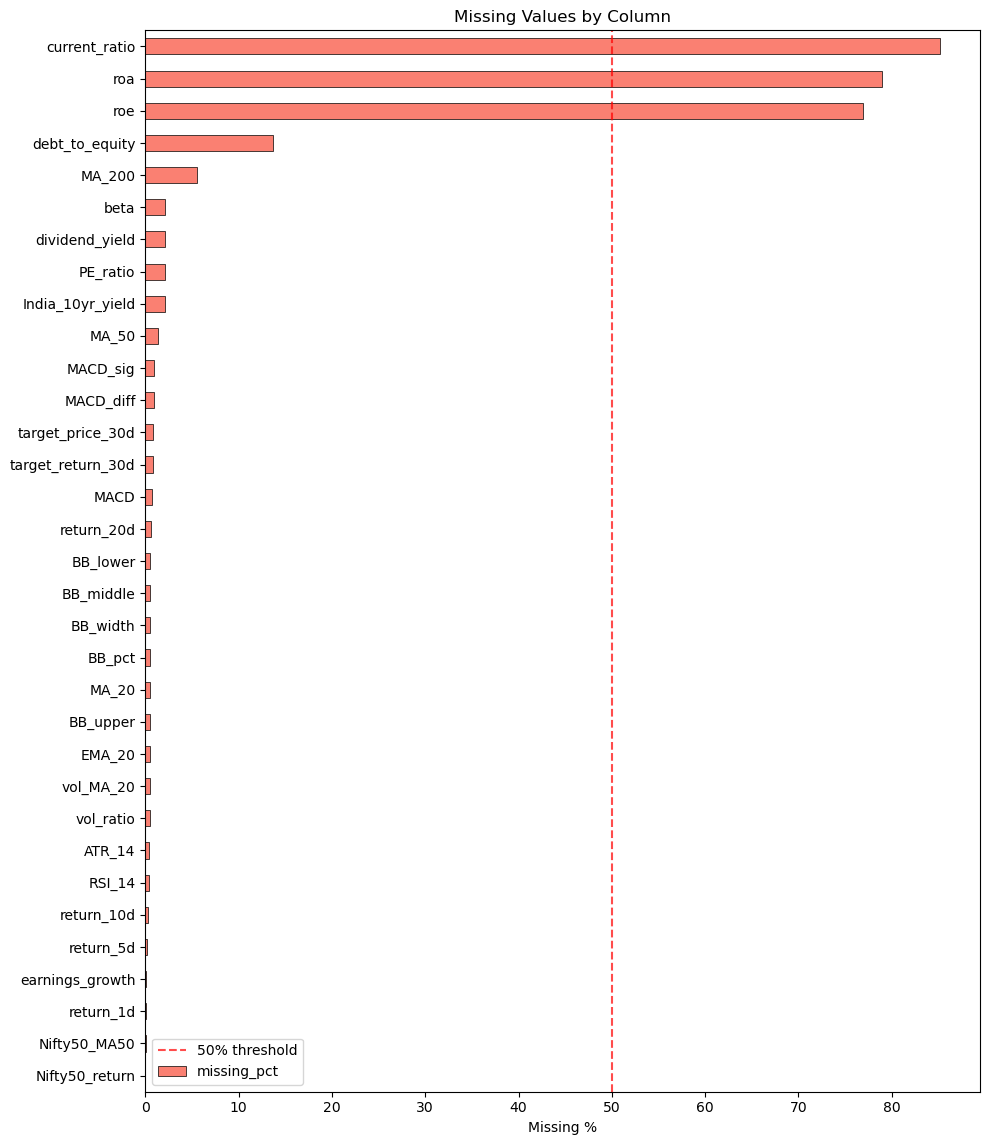

In [7]:
# Visualize missing values
if len(nan_summary) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(nan_summary) * 0.35)))
    nan_summary['missing_pct'].sort_values().plot(
        kind='barh', ax=ax, color='salmon', edgecolor='black', linewidth=0.5
    )
    ax.axvline(x=50, color='red', linestyle='--', alpha=0.7, label='50% threshold')
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Values by Column')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [8]:
# ── Strategy per column group ──────────────────────────────────────────────
#
# Technical indicators (MA, RSI, MACD, BB, ATR):
#   → NaN in first N rows (warmup period). Drop these rows per stock.
#
# Macro columns (USD_INR, Gold, Oil, Nifty50):
#   → Weekend/holiday gaps. Forward-fill per date.
#
# Fundamental columns (PE, EPS, margins etc.):
#   → Static snapshot — fill with sector median.
#
# Target column (target_return_30d):
#   → NaN in last 30 rows per stock (no future data yet). Drop these rows.
# ─────────────────────────────────────────────────────────────────────────

print('NaN strategy defined ✅')

NaN strategy defined ✅


In [9]:
# 3a. Forward-fill macro columns (gaps from weekends/holidays)
macro_cols = ['USD_INR', 'Nifty50_close', 'Nifty50_return', 'Nifty50_MA50',
              'Gold_price', 'Crude_oil_price', 'India_10yr_yield']
macro_cols = [c for c in macro_cols if c in df.columns]

df[macro_cols] = df[macro_cols].ffill()
print(f'✅ Forward-filled {len(macro_cols)} macro columns')
print(f'   Remaining NaNs in macro: {df[macro_cols].isnull().sum().sum()}')

✅ Forward-filled 7 macro columns
   Remaining NaNs in macro: 3743


In [10]:
# 3b. Drop rows where target is NaN (last 30 rows per stock — no future price yet)
before = len(df)
df = df.dropna(subset=['target_return_30d', 'target_price_30d'])
after = len(df)
print(f'✅ Dropped {before - after:,} rows with NaN target (last 30 days per stock)')
print(f'   Remaining rows: {after:,}')

✅ Dropped 1,500 rows with NaN target (last 30 days per stock)
   Remaining rows: 176,353


In [11]:
# 3c. Drop rows with NaN in technical indicators (warmup period rows)
tech_cols = ['MA_20', 'MA_50', 'MA_200', 'EMA_20', 'RSI_14',
             'MACD', 'MACD_sig', 'MACD_diff',
             'BB_upper', 'BB_lower', 'BB_width', 'BB_pct',
             'ATR_14', 'return_20d']
tech_cols = [c for c in tech_cols if c in df.columns]

before = len(df)
df = df.dropna(subset=tech_cols)
after = len(df)
print(f'✅ Dropped {before - after:,} warmup rows (technical indicators not yet computed)')
print(f'   Remaining rows: {after:,}')

✅ Dropped 9,835 warmup rows (technical indicators not yet computed)
   Remaining rows: 166,518


In [12]:
# 3d. Fill fundamental NaNs with sector/overall median
fundamental_cols = [
    'PE_ratio', 'forward_PE', 'EPS_trailing', 'EPS_forward',
    'revenue_growth', 'earnings_growth', 'profit_margin', 'operating_margin',
    'debt_to_equity', 'current_ratio', 'roe', 'roa',
    'book_value', 'price_to_book', 'dividend_yield', 'market_cap',
    '52w_high', '52w_low', 'beta'
]
fundamental_cols = [c for c in fundamental_cols if c in df.columns]

for col in fundamental_cols:
    median_val = df[col].median()
    nan_count  = df[col].isnull().sum()
    if nan_count > 0:
        df[col] = df[col].fillna(median_val)
        print(f'   Filled {nan_count:>6,} NaNs in {col:25s} with median={median_val:.4f}')

print(f'\n✅ Fundamental NaNs filled with column medians')

   Filled  3,464 NaNs in PE_ratio                  with median=26.3777
   Filled 22,655 NaNs in debt_to_equity            with median=38.1490
   Filled 142,024 NaNs in current_ratio             with median=1.8800
   Filled 128,168 NaNs in roe                       with median=0.1680
   Filled 131,632 NaNs in roa                       with median=0.0677
   Filled  3,464 NaNs in dividend_yield            with median=1.0100
   Filled  3,464 NaNs in beta                      with median=0.3140

✅ Fundamental NaNs filled with column medians


In [13]:
# 3e. Final NaN check — should be near zero
remaining_nans = df.isnull().sum()
remaining_nans = remaining_nans[remaining_nans > 0]

if len(remaining_nans) == 0:
    print('✅ No remaining NaNs! Dataset is complete.')
else:
    print(f'⚠️  {len(remaining_nans)} columns still have NaNs:')
    print(remaining_nans.to_string())
    # Drop any remaining NaN rows as last resort
    before = len(df)
    df = df.dropna()
    print(f'   Dropped {before - len(df):,} remaining NaN rows')

⚠️  1 columns still have NaNs:
India_10yr_yield    3464
   Dropped 3,464 remaining NaN rows


---
## Step 4 — Remove Outliers

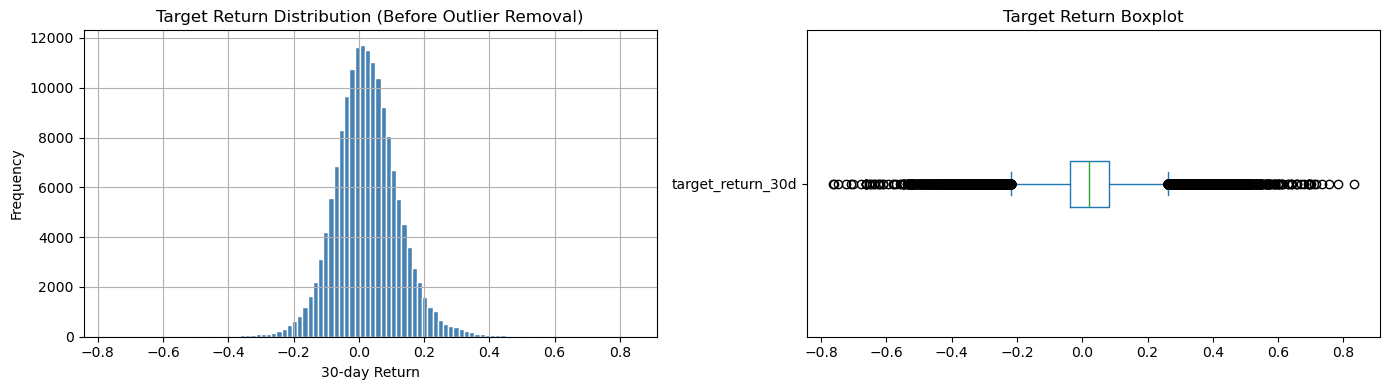

Target stats:
count   163054.0000
mean         0.0238
std          0.1007
min         -0.7637
25%         -0.0379
50%          0.0202
75%          0.0821
max          0.8327
Name: target_return_30d, dtype: float64


In [14]:
# Visualize target distribution before cleaning
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['target_return_30d'].hist(bins=100, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Target Return Distribution (Before Outlier Removal)')
axes[0].set_xlabel('30-day Return')
axes[0].set_ylabel('Frequency')

df['target_return_30d'].plot(kind='box', ax=axes[1], vert=False)
axes[1].set_title('Target Return Boxplot')

plt.tight_layout()
plt.show()

print(f'Target stats:')
print(df['target_return_30d'].describe())

In [15]:
# Remove extreme outliers using IQR on target column
# Keeping returns within [-60%, +100%] — anything beyond is likely data error
Q1  = df['target_return_30d'].quantile(0.01)
Q99 = df['target_return_30d'].quantile(0.99)

before = len(df)
df = df[(df['target_return_30d'] >= Q1) & (df['target_return_30d'] <= Q99)]
after = len(df)

print(f'✅ Removed {before - after:,} extreme outlier rows')
print(f'   Target range after: [{Q1:.4f}, {Q99:.4f}]')
print(f'   Remaining rows: {after:,}')

✅ Removed 3,262 extreme outlier rows
   Target range after: [-0.2160, 0.2971]
   Remaining rows: 159,792


In [16]:
# Remove outliers in price and volume columns using per-stock z-score
price_vol_cols = ['close', 'volume', 'ATR_14']
price_vol_cols = [c for c in price_vol_cols if c in df.columns]

before = len(df)
for col in price_vol_cols:
    z = (df[col] - df.groupby('Ticker')[col].transform('mean')) / \
         df.groupby('Ticker')[col].transform('std')
    df = df[z.abs() < 5]   # remove rows > 5 std deviations per stock

after = len(df)
print(f'✅ Removed {before - after:,} extreme price/volume outlier rows')
print(f'   Remaining rows: {after:,}')

✅ Removed 1,024 extreme price/volume outlier rows
   Remaining rows: 158,768


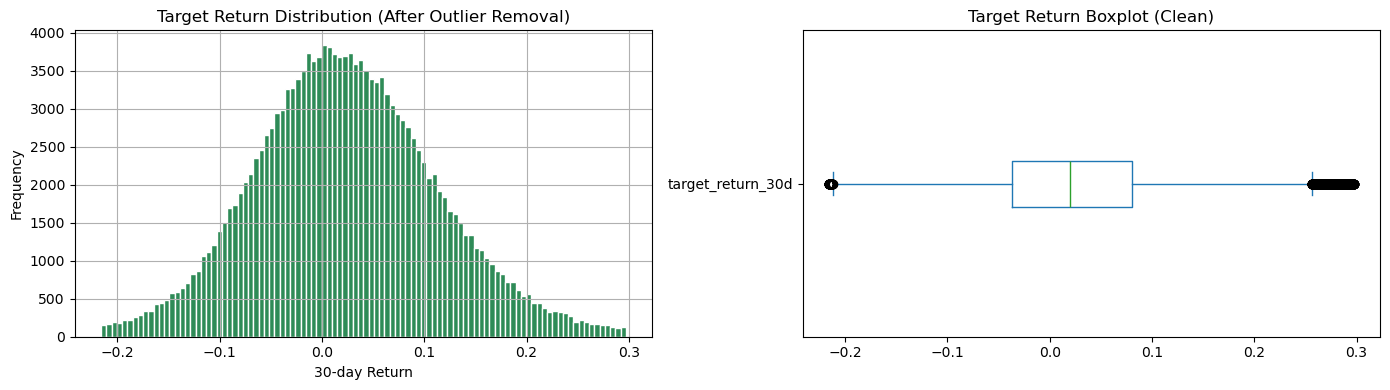

count   158768.0000
mean         0.0235
std          0.0888
min         -0.2160
25%         -0.0366
50%          0.0202
75%          0.0806
max          0.2971
Name: target_return_30d, dtype: float64


In [17]:
# Plot target distribution after outlier removal
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['target_return_30d'].hist(bins=100, ax=axes[0], color='seagreen', edgecolor='white')
axes[0].set_title('Target Return Distribution (After Outlier Removal)')
axes[0].set_xlabel('30-day Return')
axes[0].set_ylabel('Frequency')

df['target_return_30d'].plot(kind='box', ax=axes[1], vert=False)
axes[1].set_title('Target Return Boxplot (Clean)')

plt.tight_layout()
plt.show()
print(df['target_return_30d'].describe())

---
## Step 5 — Drop Leakage & Unnecessary Columns

In [18]:
# Columns to drop:
# - target_price_30d  : raw future price — leaks future info (we keep return instead)
# - BB_middle         : identical to MA_20, redundant
# - 52w_high/52w_low  : point-in-time snapshot, not time-series safe
# - market_cap        : highly correlated with price, adds noise

drop_cols = ['target_price_30d', 'BB_middle', '52w_high', '52w_low', 'market_cap']
drop_cols = [c for c in drop_cols if c in df.columns]

df = df.drop(columns=drop_cols)
print(f'✅ Dropped {len(drop_cols)} columns: {drop_cols}')
print(f'   Remaining columns: {df.shape[1]}')

✅ Dropped 5 columns: ['target_price_30d', 'BB_middle', '52w_high', '52w_low', 'market_cap']
   Remaining columns: 50


In [19]:
# Check for duplicate rows
dupes = df.duplicated(subset=['date', 'Ticker']).sum()
print(f'Duplicate (date, Ticker) pairs: {dupes}')
if dupes > 0:
    df = df.drop_duplicates(subset=['date', 'Ticker'])
    print(f'✅ Dropped {dupes} duplicate rows')

Duplicate (date, Ticker) pairs: 0


---
## Step 6 — Verify Target Column & Feature Correlations

In [20]:
# Target column stats per stock
target_stats = df.groupby('Ticker')['target_return_30d'].agg(['mean', 'std', 'min', 'max'])
target_stats.columns = ['Mean Return', 'Std Dev', 'Min Return', 'Max Return']
target_stats = target_stats.round(4).sort_values('Mean Return', ascending=False)
print('Top 10 stocks by avg 30-day return:')
print(target_stats.head(10).to_string())
print('\nBottom 10 stocks by avg 30-day return:')
print(target_stats.tail(10).to_string())

Top 10 stocks by avg 30-day return:
               Mean Return  Std Dev  Min Return  Max Return
Ticker                                                     
BAJFINANCE.NS       0.0494   0.1019     -0.2160      0.2967
EICHERMOT.NS        0.0378   0.1013     -0.2156      0.2962
BAJAJFINSV.NS       0.0329   0.1000     -0.2150      0.2967
BRITANNIA.NS        0.0323   0.0857     -0.2110      0.2912
TITAN.NS            0.0313   0.0946     -0.2159      0.2962
DIVISLAB.NS         0.0306   0.0877     -0.2143      0.2928
TECHM.NS            0.0305   0.0934     -0.2143      0.2937
HCLTECH.NS          0.0295   0.0873     -0.2150      0.2948
MARUTI.NS           0.0290   0.0899     -0.2139      0.2946
APOLLOHOSP.NS       0.0272   0.0874     -0.2144      0.2970

Bottom 10 stocks by avg 30-day return:
               Mean Return  Std Dev  Min Return  Max Return
Ticker                                                     
TCS.NS              0.0184   0.0756     -0.2144      0.2955
DRREDDY.NS          0.01

In [21]:
# Correlation of features with target
feature_cols = [c for c in df.columns if c not in ['date', 'Ticker', 'target_return_30d']]
correlations  = df[feature_cols + ['target_return_30d']].corr()['target_return_30d'] \
                  .drop('target_return_30d').sort_values(key=abs, ascending=False)

print('Top 15 features most correlated with target:')
print(correlations.head(15).round(4).to_string())
print('\nBottom 5 features least correlated with target:')
print(correlations.tail(5).round(4).to_string())

Top 15 features most correlated with target:
BB_width          0.0627
Nifty50_close    -0.0615
Nifty50_MA50     -0.0593
MACD_sig         -0.0427
MACD             -0.0402
Gold_price       -0.0383
debt_to_equity    0.0374
RSI_14           -0.0343
dividend_yield   -0.0324
low              -0.0316
close            -0.0315
open             -0.0314
high             -0.0314
BB_lower         -0.0312
MA_20            -0.0306

Bottom 5 features least correlated with target:
earnings_growth    -0.0029
Nifty50_return      0.0026
vol_ratio          -0.0016
MACD_diff          -0.0008
India_10yr_yield       NaN


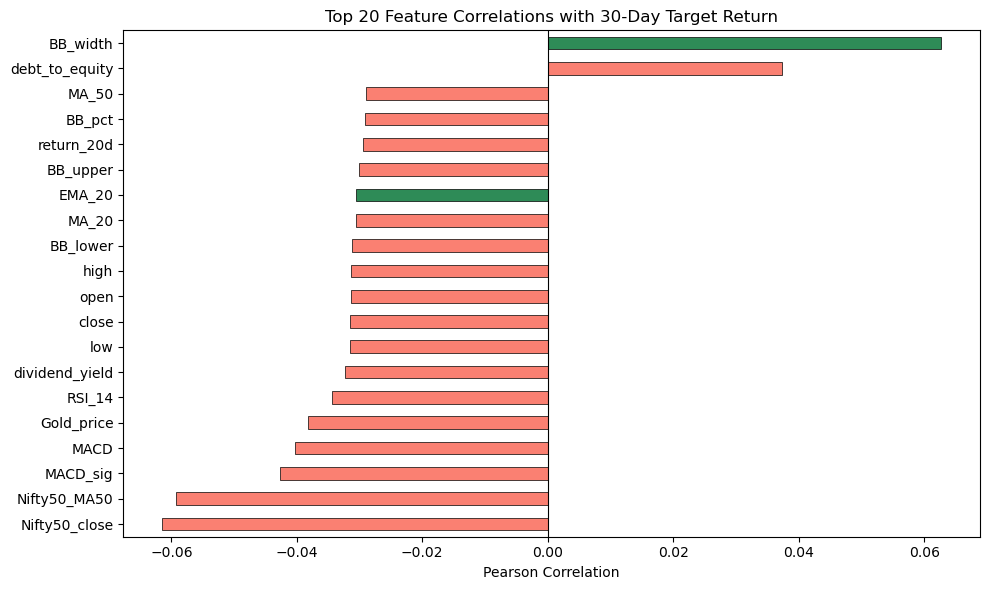

In [22]:
# Plot top 20 correlations
top20 = correlations.head(20)
colors = ['seagreen' if v > 0 else 'salmon' for v in top20.values]

fig, ax = plt.subplots(figsize=(10, 6))
top20.sort_values().plot(kind='barh', ax=ax, color=colors[::-1], edgecolor='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Top 20 Feature Correlations with 30-Day Target Return')
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

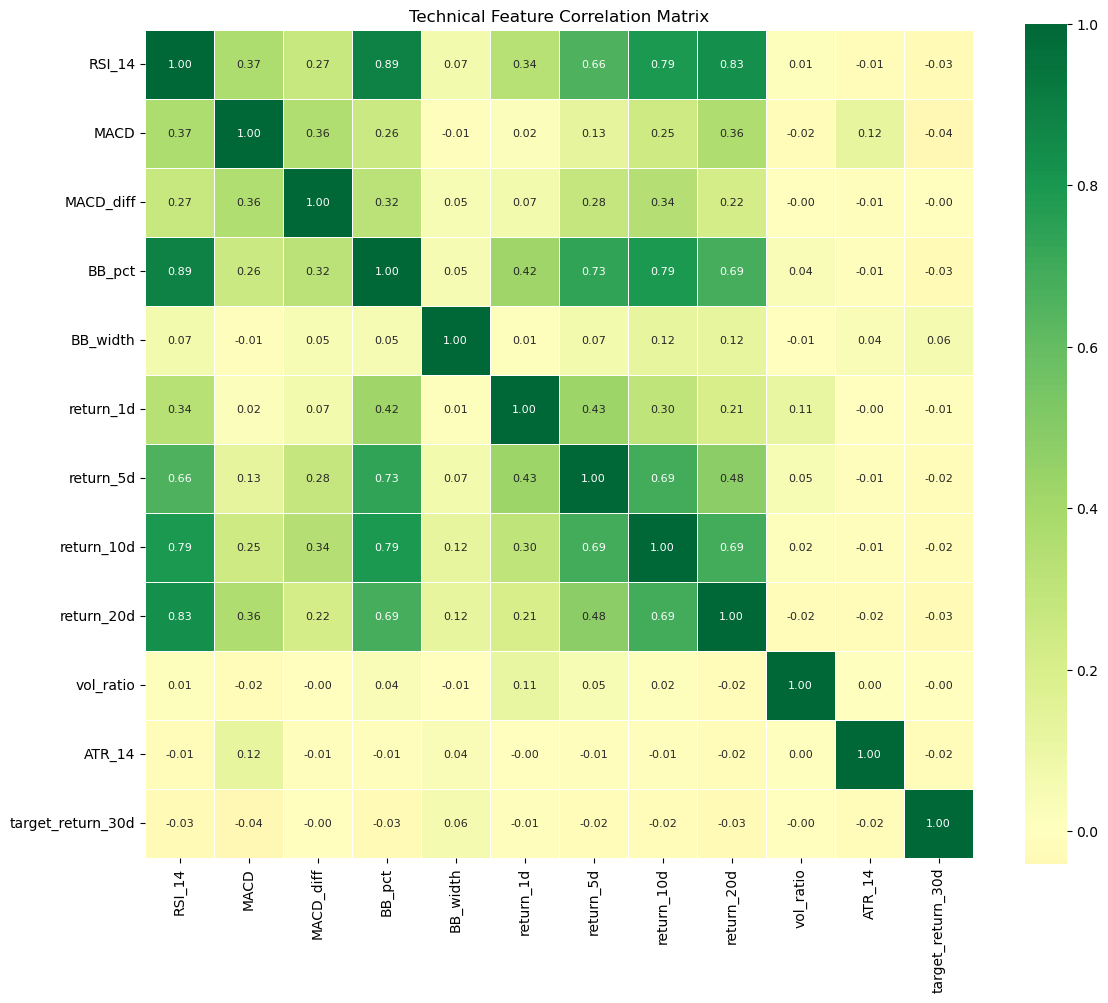

In [23]:
# Correlation heatmap for technical features
tech_feature_cols = ['RSI_14', 'MACD', 'MACD_diff', 'BB_pct', 'BB_width',
                     'return_1d', 'return_5d', 'return_10d', 'return_20d',
                     'vol_ratio', 'ATR_14', 'target_return_30d']
tech_feature_cols = [c for c in tech_feature_cols if c in df.columns]

fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df[tech_feature_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Technical Feature Correlation Matrix')
plt.tight_layout()
plt.show()

---
## Step 7 — Final Summary & Save

In [24]:
# Final dataset overview
print('=' * 55)
print('  CLEANED DATASET SUMMARY')
print('=' * 55)
print(f'  Rows             : {len(df):,}')
print(f'  Columns          : {df.shape[1]}')
print(f'  Stocks           : {df["Ticker"].nunique()}')
print(f'  Date range       : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'  Remaining NaNs   : {df.isnull().sum().sum()}')
print(f'  Memory usage     : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print('=' * 55)
print(f'\n  Rows removed during cleaning:')
print(f'  Original → Cleaned: 177,853 → {len(df):,} ({177853 - len(df):,} removed)')
print('=' * 55)

  CLEANED DATASET SUMMARY
  Rows             : 158,768
  Columns          : 50
  Stocks           : 48
  Date range       : 2012-02-01 → 2026-02-16
  Remaining NaNs   : 0
  Memory usage     : 72.9 MB

  Rows removed during cleaning:
  Original → Cleaned: 177,853 → 158,768 (19,085 removed)


In [25]:
# Final column list
print(f'Final {df.shape[1]} columns:\n')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2d}. {col}')

Final 50 columns:

   1. date
   2. close
   3. high
   4. low
   5. open
   6. volume
   7. Ticker
   8. MA_20
   9. MA_50
  10. MA_200
  11. EMA_20
  12. RSI_14
  13. MACD
  14. MACD_sig
  15. MACD_diff
  16. BB_upper
  17. BB_lower
  18. BB_width
  19. BB_pct
  20. return_1d
  21. return_5d
  22. return_10d
  23. return_20d
  24. vol_MA_20
  25. vol_ratio
  26. ATR_14
  27. target_return_30d
  28. USD_INR
  29. Nifty50_close
  30. Nifty50_return
  31. Nifty50_MA50
  32. India_10yr_yield
  33. Gold_price
  34. Crude_oil_price
  35. PE_ratio
  36. forward_PE
  37. EPS_trailing
  38. EPS_forward
  39. revenue_growth
  40. earnings_growth
  41. profit_margin
  42. operating_margin
  43. debt_to_equity
  44. current_ratio
  45. roe
  46. roa
  47. book_value
  48. price_to_book
  49. dividend_yield
  50. beta


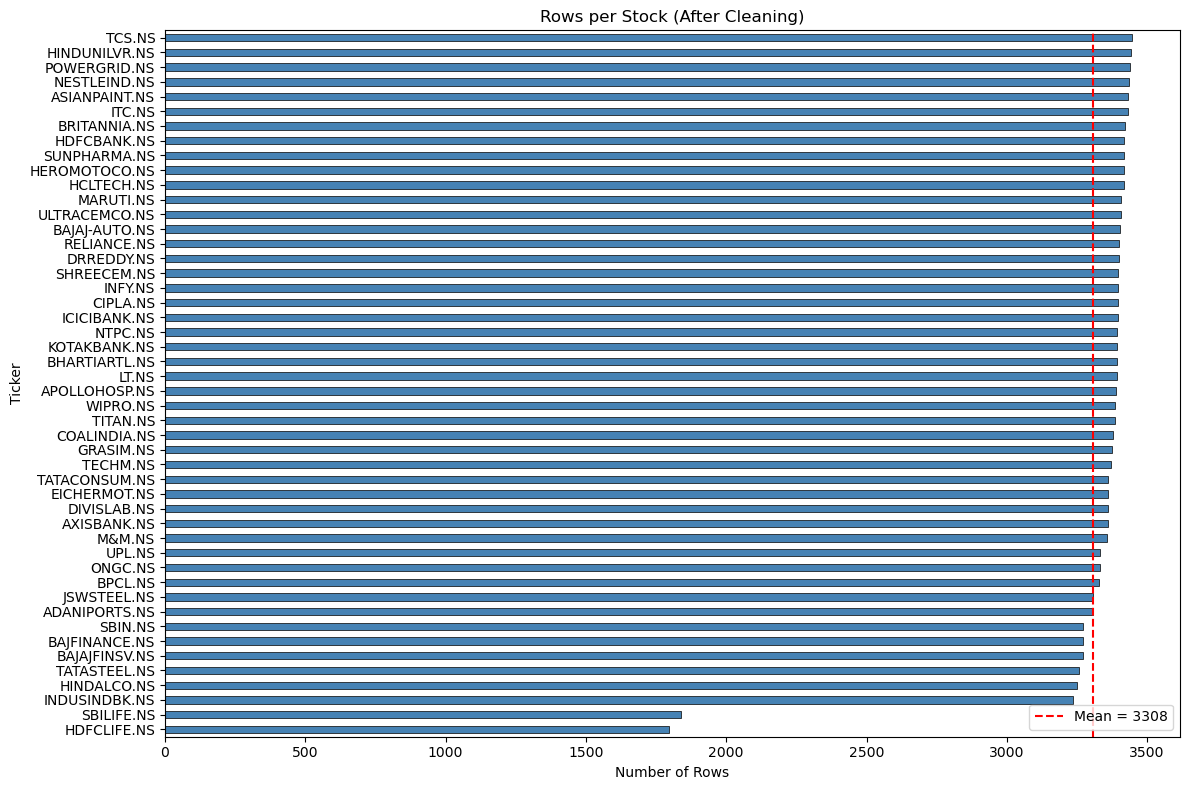

In [26]:
# Per-stock row count after cleaning
rows_per_stock_clean = df.groupby('Ticker').size().sort_values()
fig, ax = plt.subplots(figsize=(12, 8))
rows_per_stock_clean.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Number of Rows')
ax.set_title('Rows per Stock (After Cleaning)')
ax.axvline(rows_per_stock_clean.mean(), color='red', linestyle='--', label=f'Mean = {rows_per_stock_clean.mean():.0f}')
ax.legend()
plt.tight_layout()
plt.show()

In [27]:
# Save cleaned dataset
output_path = 'nifty50_data/nifty50_cleaned.csv'
df.to_csv(output_path, index=False)
print(f'✅ Cleaned dataset saved → {output_path}')
print(f'   Shape: {df.shape}')
print(f'\n🚀 Ready for Step 3: Feature Engineering & Model Training!')

✅ Cleaned dataset saved → nifty50_data/nifty50_cleaned.csv
   Shape: (158768, 50)

🚀 Ready for Step 3: Feature Engineering & Model Training!


In [28]:
df

,date,close,high,low,open,volume,Ticker,MA_20,MA_50,MA_200,EMA_20,RSI_14,MACD,MACD_sig,MACD_diff,BB_upper,BB_lower,BB_width,BB_pct,return_1d,return_5d,return_10d,return_20d,vol_MA_20,vol_ratio,ATR_14,target_return_30d,USD_INR,Nifty50_close,Nifty50_return,Nifty50_MA50,India_10yr_yield,Gold_price,Crude_oil_price,PE_ratio,forward_PE,EPS_trailing,EPS_forward,revenue_growth,earnings_growth,profit_margin,operating_margin,debt_to_equity,current_ratio,roe,roa,book_value,price_to_book,dividend_yield,beta
3892,2012-02-01,133.3033,136.8698,131.6822,135.7582,899183,ADANIPORTS.NS,128.8035,121.0930,134.7315,129.5535,54.8758,4.0615,3.8603,0.2012,144.7164,112.8906,24.7088,0.6414,-0.0161,-0.0410,0.0279,0.1962,1207287.0000,0.7448,6.6996,-0.0728,49.5000,5235.7002,0.0070,4861.5850,2569.1001,1747.1000,97.6100,23.8669,19.7968,57.7200,69.5869,0.2190,0.2030,0.3424,0.4536,81.5560,1.8800,0.1941,0.0677,310.4640,4.4372,0.5100,0.3320
3893,2012-02-02,139.8805,140.6216,133.8591,133.8591,2355597,ADANIPORTS.NS,130.1074,121.4385,134.7564,130.5370,59.7393,4.3710,3.9624,0.4086,145.1393,115.0754,23.1070,0.8251,0.0493,0.0545,0.0656,0.2291,1262104.4000,1.8664,6.8054,-0.1250,49.0100,5269.8999,0.0065,4868.2880,2569.1001,1756.8000,96.3600,23.8669,19.7968,57.7200,69.5869,0.2190,0.2030,0.3424,0.4536,81.5560,1.8800,0.1941,0.0677,310.4640,4.4372,0.5100,0.3320
3894,2012-02-03,139.1857,141.4553,137.3330,139.8805,814359,ADANIPORTS.NS,131.1982,121.9332,134.7724,131.3607,59.0157,4.5083,4.0716,0.4367,145.5242,116.8721,21.8388,0.7788,-0.0050,0.0214,0.0057,0.1859,1263402.1000,0.6446,6.8716,-0.1173,49.0000,5325.8501,0.0106,4876.6890,2569.1001,1737.9000,97.8400,23.8669,19.7968,57.7200,69.5869,0.2190,0.2030,0.3424,0.4536,81.5560,1.8800,0.1941,0.0677,310.4640,4.4372,0.5100,0.3320
3895,2012-02-06,137.1940,141.5942,135.5266,141.5942,1518103,ADANIPORTS.NS,132.1431,122.4964,134.7839,131.9162,56.8884,4.4056,4.1384,0.2672,145.3930,118.8931,20.0540,0.6906,-0.0143,0.0701,-0.0470,0.1597,1287476.1000,1.1791,7.3050,-0.1126,48.6530,5361.6499,0.0067,4888.3550,2569.1001,1722.8000,96.9100,23.8669,19.7968,57.7200,69.5869,0.2190,0.2030,0.3424,0.4536,81.5560,1.8800,0.1941,0.0677,310.4640,4.4372,0.5100,0.3320
3896,2012-02-07,128.9031,138.4446,127.6988,138.1667,1735290,ADANIPORTS.NS,132.4650,122.7891,134.7353,131.6293,48.9745,3.6136,4.0334,-0.4199,145.0552,119.8747,19.0091,0.3585,-0.0604,-0.0485,-0.0518,0.0526,1331825.6000,1.3029,7.4473,-0.0933,49.0530,5335.1499,-0.0049,4898.8110,2569.1001,1746.4000,98.4100,23.8669,19.7968,57.7200,69.5869,0.2190,0.2030,0.3424,0.4536,81.5560,1.8800,0.1941,0.0677,310.4640,4.4372,0.5100,0.3320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177818,2026-02-10,231.4700,232.8600,227.2000,229.9800,12435622,WIPRO.NS,239.6274,249.3266,243.6812,239.2188,37.6266,-5.2427,-4.6224,-0.6203,257.9333,221.3216,15.2786,0.2772,0.0060,-0.0462,-0.0142,-0.0975,15063532.8000,0.8255,6.4855,-0.1833,90.8228,25935.1504,0.0026,25818.8671,2569.1001,5003.7998,63.9600,15.4568,14.4203,12.6100,13.5164,0.0550,-0.0720,0.1459,0.1484,22.0310,2.1850,0.1520,0.0677,85.6120,2.2767,8.7200,0.3830
177819,2026-02-11,229.8100,233.0000,229.5000,231.4700,7874912,WIPRO.NS,238.2404,249.0432,243.6787,238.3227,36.1212,-5.3348,-4.7649,-0.5699,255.0462,221.4346,14.1083,0.2492,-0.0072,-0.0151,-0.0318,-0.1077,15110716.2000,0.5211,6.3874,-0.1663,90.5879,25953.8496,0.0007,25813.8852,2569.1001,5071.6001,64.6300,15.4568,14.4203,12.6100,13.5164,0.0550,-0.0720,0.1459,0.1484,22.0310,2.1850,0.1520,0.0677,85.6120,2.2767,8.7200,0.3830
177820,2026-02-12,219.0800,226.2600,218.5000,226.2000,40899346,WIPRO.NS,236.5118,248.5473,243.6245,236.4901,28.2523,-6.2021,-5.0523,-1.1497,253.7284,219.2953,14.5587,-0.0063,-0.0467,-0.0613,-0.0864,-0.1363,16874390.4500,2.4238,6.9376,-0.1435,90.7357,25807.1992,-0.0057,25806.5141,2569.1001,4923.7002,62.8400,15.4568,14.4203,12.6100,13.5164,0.0550,-0.0720